El dataset tiene 1000 filas y 10 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   object 
 1   Date           1000 non-null   object 
 2   Brand          1000 non-null   object 
 3   Shoe_Type      1000 non-null   object 
 4   Color          1000 non-null   object 
 5   Country        1000 non-null   object 
 6   Sales_Channel  1000 non-null   object 
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 78.3+ KB
Brand: ['Nike', 'Skechers', 'New Balance', 'Adidas', 'Puma', 'Reebok']
Shoe_Type: ['Boots', 'Running', 'Casual', 'Formal', 'Sports', 'Sneakers']
Color: ['Blue', 'Grey', 'White', 'Green', 'Red', 'Black']
Country: ['UK', 'USA', 'UAE', 'France', 'Saudi Arabia', '

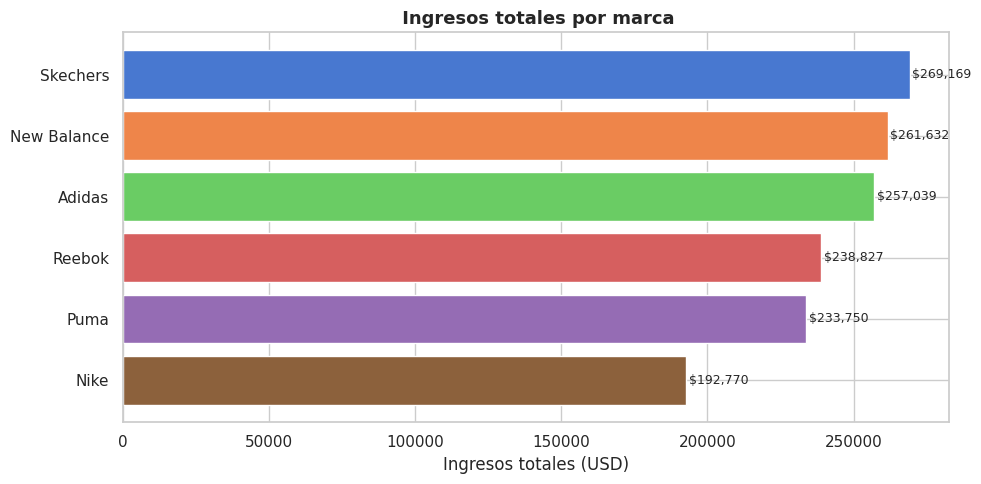

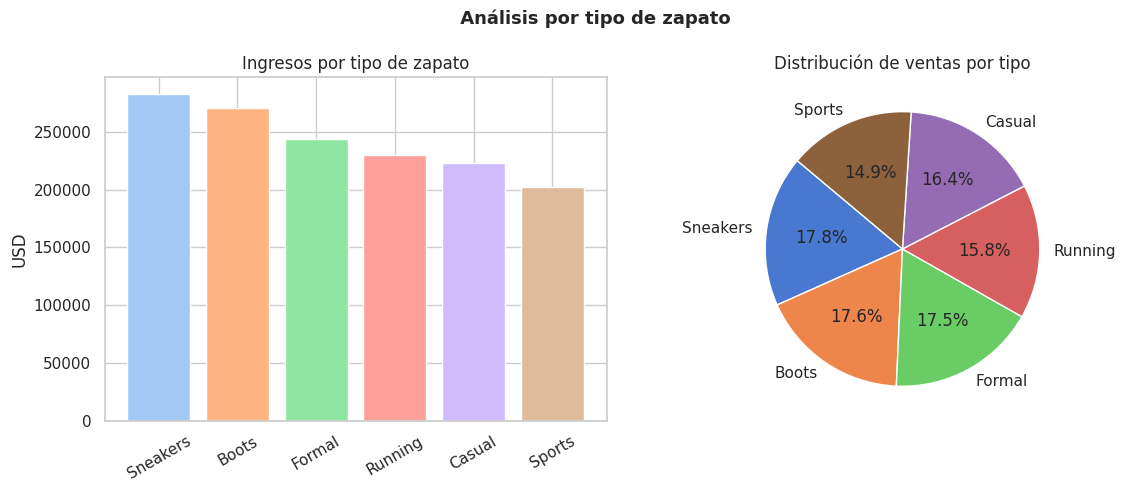

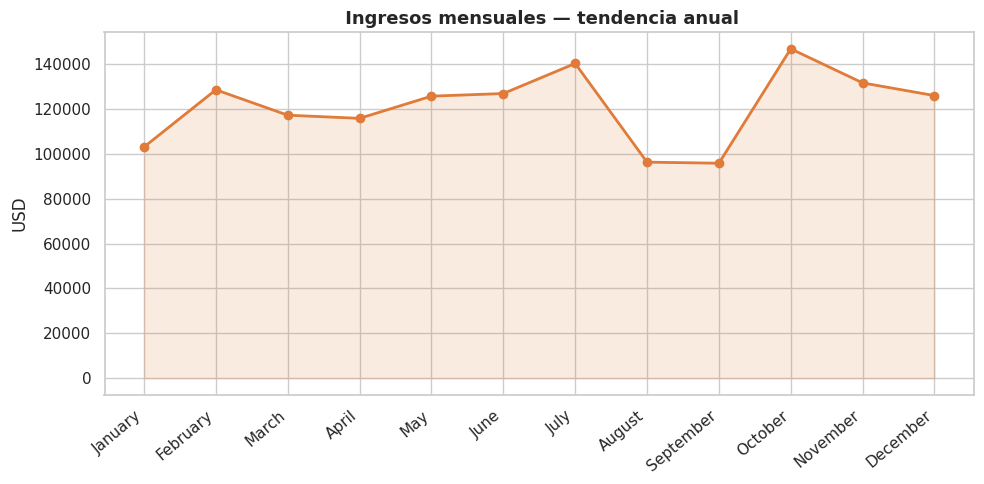

Ingresos por canal y país:


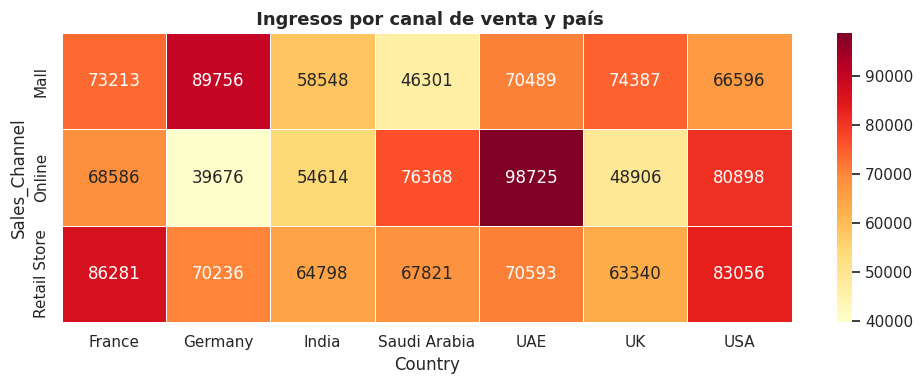

Top 5 ventas más grandes:
Participación de mercado (%):
Brand
Skechers       18.52
New Balance    18.00
Adidas         17.69
Reebok         16.43
Puma           16.09
Nike           13.27
Name: Revenue_USD, dtype: float64
Ventas que superan la media de su marca: 405 de 1000 (40.5%)

Las 5 ventas más rentables del dataset:


 RESUMEN FINAL DEL ANÁLISIS 

 Dataset : 1,000 transacciones de calzado 
 Ingresos tot. : $1,453,186.03 USD 
 Marca líder : Skechers             
 Mejor tipo : Sneakers                             
 Canal top : Retail Store                         
 País top : UAE                                  
 Mes pico : October                              

 CONCLUSIONES PRINCIPALES:

1. El dataset está bien estructurado: sin nulos ni duplicados.
 Esto facilitó el análisis sin necesidad de imputación.

2. Skechers lidera el mercado con $269,169 USD en ingresos,
 aunque la diferencia con otras marcas no es abismal —
 el mercado está bastante competitivo entre las 6 marcas.

3.

In [4]:
# TALLER PANDAS — Análisis de Ventas de Calzado

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

# 1 — Cargando y explorando el dataset

df = pd.read_csv("shoes_sales_dataset.csv")

print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas\n")
df.head(10)

# Un vistazo a los tipos de datos y valores nulos
df.info()

# Estadísticas básicas de las columnas numéricas
df.describe().round(2)

# ¿Qué valores únicos hay en cada columna de texto?
columnas_texto = ["Brand", "Shoe_Type", "Color", "Country", "Sales_Channel"]

for col in columnas_texto:
 print(f"{col}: {df[col].unique().tolist()}")

# 2 — Limpieza y transformación de datos

# Valores nulos
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\n¿Hay algún nulo? {'Sí ' if nulos.sum() > 0 else 'No, todo limpio '}")

# Duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

# Convertir 'Date' a datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extraer mes, año y trimestre (útil para analizar tendencias)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%B")
df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

print(f"Columnas de fecha creadas")
df[["Date", "Year", "Month", "Month_Name", "Quarter"]].head(5)

# Nueva columna: categoría de precio
def categorizar_precio(precio):
 if precio < 80:
  return "Económico"
 elif precio < 160:
  return "Medio"
 else:
  return "Premium"

df["Precio_Cat"] = df["Price_USD"].apply(categorizar_precio)

print("Distribución de categorías de precio:")
print(df["Precio_Cat"].value_counts())

# Verificar que Revenue = Price × Units
df["Revenue_Check"] = (df["Price_USD"] * df["Units_Sold"]).round(2)
diferencias = (df["Revenue_USD"].round(2) != df["Revenue_Check"]).sum()

print(f"Filas con Revenue inconsistente: {diferencias}")
df.drop(columns=["Revenue_Check"], inplace=True)

print("\n Dataset transformado — primeras filas:")
df.head()

# 3 — Filtros y selección de datos

# Ventas de Nike
nike = df[df["Brand"] == "Nike"]
print(f"Nike tiene {len(nike)} registros en el dataset")
nike.head()

# Filtro combinado
# Zapatos Adidas, vendidos Online, con precio Premium
filtro = (
 (df["Brand"] == "Adidas") &
 (df["Sales_Channel"] == "Online") &
 (df["Precio_Cat"] == "Premium")
)

resultado = df[filtro]
print(f"Adidas + Online + Premium → {len(resultado)} ventas")
resultado[["Date", "Shoe_Type", "Country", "Price_USD", "Units_Sold", "Revenue_USD"]].head(8)

# Ventas en Europa
europa = df[df["Country"].isin(["UK", "France", "Germany"])]
print(f"Ventas registradas en Europa: {len(europa)}")
europa["Brand"].value_counts()

# loc vs iloc
print(f".loc — por etiqueta de columna:")
print(df.loc[0:4, ["Brand", "Shoe_Type", "Price_USD", "Revenue_USD"]])

print("\n .iloc — por posición numérica:")
print(df.iloc[0:3, 0:5])

# 4 — Agrupaciones y análisis

# Ingresos totales por marca
ingresos_marca = (
 df.groupby("Brand")["Revenue_USD"]
 .sum()
 .sort_values(ascending=False)
 .reset_index()
)
ingresos_marca.columns = ["Marca", "Ingresos_USD"]
ingresos_marca["Ingresos_USD"] = ingresos_marca["Ingresos_USD"].round(2)

print(ingresos_marca.to_string(index=False))

# Visualización — Ingresos por marca
fig, ax = plt.subplots()
colores = sns.color_palette("muted", len(ingresos_marca))

ax.barh(ingresos_marca["Marca"], ingresos_marca["Ingresos_USD"], color=colores)
ax.set_xlabel("Ingresos totales (USD)")
ax.set_title(" Ingresos totales por marca", fontsize=13, fontweight="bold")
ax.invert_yaxis()

for i, val in enumerate(ingresos_marca["Ingresos_USD"]):
 ax.text(val + 1000, i, f"${val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Estadísticas por tipo de zapato
stats_tipo = df.groupby("Shoe_Type").agg(
 Ventas = ("Sale_ID", "count"),
 Precio_Prom = ("Price_USD", "mean"),
 Unidades_Prom = ("Units_Sold", "mean"),
 Ingresos_Total= ("Revenue_USD","sum")
).round(2).sort_values("Ingresos_Total", ascending=False)

stats_tipo

# Visualización — Ventas por tipo de zapato
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(stats_tipo.index, stats_tipo["Ingresos_Total"],
 color=sns.color_palette("pastel"))
axes[0].set_title("Ingresos por tipo de zapato")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(stats_tipo["Ventas"], labels=stats_tipo.index,
 autopct="%1.1f%%", startangle=140,
 colors=sns.color_palette("muted"))
axes[1].set_title("Distribución de ventas por tipo")

plt.suptitle(" Análisis por tipo de zapato", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Ingresos mensuales
orden_meses = ["January","February","March","April","May","June",
 "July","August","September","October","November","December"]

ingresos_mes = (
 df.groupby("Month_Name")["Revenue_USD"]
 .sum()
 .reindex(orden_meses)
 .reset_index()
)
ingresos_mes.columns = ["Mes", "Ingresos_USD"]

# Tendencia mensual
plt.figure()
plt.plot(ingresos_mes["Mes"], ingresos_mes["Ingresos_USD"],
 marker="o", linewidth=2, color="#e07b39")
plt.fill_between(range(len(ingresos_mes)), ingresos_mes["Ingresos_USD"],
 alpha=0.15, color="#e07b39")
plt.xticks(range(len(ingresos_mes)), ingresos_mes["Mes"], rotation=40, ha="right")
plt.title(" Ingresos mensuales — tendencia anual", fontsize=13, fontweight="bold")
plt.ylabel("USD")
plt.tight_layout()
plt.show()

# Canal de venta por país (tabla cruzada)
pivot = df.pivot_table(
 values="Revenue_USD",
 index="Sales_Channel",
 columns="Country",
 aggfunc="sum"
).round(0)

print(f"Ingresos por canal y país:")
pivot

# Heatmap del pivot
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title(" Ingresos por canal de venta y país", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top 5 ventas individuales
top5 = df.nlargest(5, "Revenue_USD")[
 ["Sale_ID", "Date", "Brand", "Shoe_Type", "Country",
 "Price_USD", "Units_Sold", "Revenue_USD"]
]
print(f"Top 5 ventas más grandes:")
top5

# 5 — Operaciones extra con Series y DataFrames

# Participación de mercado por marca
total = df["Revenue_USD"].sum()
participacion = (
 df.groupby("Brand")["Revenue_USD"].sum() / total * 100
).round(2).sort_values(ascending=False)

print(f"Participación de mercado (%):")
print(participacion)

# Comparar cada venta con la media de su marca
df["Media_Marca"] = df.groupby("Brand")["Revenue_USD"].transform("mean").round(2)
df["Dif_vs_Media"] = (df["Revenue_USD"] - df["Media_Marca"]).round(2)

por_encima = (df["Dif_vs_Media"] > 0).sum()
print(f"Ventas que superan la media de su marca: {por_encima} de {len(df)} ({por_encima/len(df)*100:.1f}%)\n")

df[["Brand", "Revenue_USD", "Media_Marca", "Dif_vs_Media"]].head(8)

# Ordenar y resetear índice
df_top = df.sort_values("Revenue_USD", ascending=False).reset_index(drop=True)

print(f"Las 5 ventas más rentables del dataset:")
df_top[["Brand", "Shoe_Type", "Country", "Price_USD", "Units_Sold", "Revenue_USD"]].head(5)

# 6 — Conclusiones

marca_top = ingresos_marca.iloc[0]["Marca"]
ing_top = ingresos_marca.iloc[0]["Ingresos_USD"]
tipo_top = stats_tipo.index[0]
canal_top = df.groupby("Sales_Channel")["Revenue_USD"].sum().idxmax()
pais_top = df.groupby("Country")["Revenue_USD"].sum().idxmax()
mes_top = ingresos_mes.loc[ingresos_mes["Ingresos_USD"].idxmax(), "Mes"]
total_ing = df["Revenue_USD"].sum()

print(f"""

 RESUMEN FINAL DEL ANÁLISIS

 Dataset : 1,000 transacciones de calzado
 Ingresos tot. : ${total_ing:>10,.2f} USD
 Marca líder : {marca_top:<20}
 Mejor tipo : {tipo_top:<36}
 Canal top : {canal_top:<36}
 País top : {pais_top:<36}
 Mes pico : {mes_top:<36}

 CONCLUSIONES PRINCIPALES:

1. El dataset está bien estructurado: sin nulos ni duplicados.
 Esto facilitó el análisis sin necesidad de imputación.

2. {marca_top} lidera el mercado con ${ing_top:,.0f} USD en ingresos,
 aunque la diferencia con otras marcas no es abismal —
 el mercado está bastante competitivo entre las 6 marcas.

3. Los {tipo_top} son los más rentables. Podrían ser el foco
 de estrategias de marketing o expansión de catálogo.

4. El canal "{canal_top}" genera más ingresos en términos absolutos,
 lo que puede orientar decisiones de inversión en canales.

5. El mes de mayor actividad es {mes_top}. Esto puede relacionarse
 con temporadas de descuentos o cambios climáticos por región.

6. La base de datos se obtuvo desde https://www.kaggle.com/datasets/syedaeman2212/shoes-sales-dataset
""")